# HAM10000 Skin Cancer Classifier

This notebook fixes the original local path issues, updates the TensorFlow/Keras API calls, and saves the trained model plus preprocessing stats for the Streamlit dashboard in `app/main.py`.

You can optionally speed up experiments with these environment variables before running the notebook:

- `SKIN_CANCER_EPOCHS`
- `SKIN_CANCER_BATCH_SIZE`
- `SKIN_CANCER_MAX_SAMPLES`


In [1]:
from pathlib import Path
import os
from glob import glob
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

sns.set_theme(style="whitegrid")
np.random.seed(1234)
tf.random.set_seed(1234)


def find_project_root(start_path):
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project data directory.")


def load_and_resize_image(image_path):
    with Image.open(image_path) as image:
        return np.asarray(image.convert("RGB").resize(IMAGE_SIZE), dtype=np.uint8)


def can_stratify(labels, holdout_size):
    labels = np.asarray(labels)
    unique_labels, counts = np.unique(labels, return_counts=True)
    if len(unique_labels) < 2 or counts.min() < 2:
        return False

    holdout_count = int(np.ceil(len(labels) * holdout_size)) if isinstance(holdout_size, float) else int(holdout_size)
    train_count = len(labels) - holdout_count
    return holdout_count >= len(unique_labels) and train_count >= len(unique_labels)


def split_dataset(*arrays, labels, test_size, random_state):
    stratify_labels = labels if can_stratify(labels, test_size) else None
    return train_test_split(*arrays, test_size=test_size, random_state=random_state, stratify=stratify_labels)


def plot_model_history(history):
    accuracy = history.history.get("accuracy") or history.history.get("acc")
    val_accuracy = history.history.get("val_accuracy") or history.history.get("val_acc")
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])
    epochs = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(epochs, accuracy, label="train")
    axes[0].plot(epochs, val_accuracy, label="validation")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(loc="best")

    axes[1].plot(epochs, loss, label="train")
    axes[1].plot(epochs, val_loss, label="validation")
    axes[1].set_title("Model Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(loc="best")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, classes, normalize=False, title="Confusion Matrix", cmap=plt.cm.Blues):
    matrix = cm.astype("float") / cm.sum(axis=1, keepdims=True) if normalize else cm

    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    threshold = matrix.max() / 2.0
    for i, j in itertools.product(range(matrix.shape[0]), range(matrix.shape[1])):
        display_value = f"{matrix[i, j]:.2f}" if normalize else str(int(matrix[i, j]))
        plt.text(
            j,
            i,
            display_value,
            horizontalalignment="center",
            color="white" if matrix[i, j] > threshold else "black",
        )

    plt.tight_layout()
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = Path(os.getenv("SKIN_CANCER_OUTPUT_DIR", str(PROJECT_ROOT / "artifacts")))
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = (100, 75)
BATCH_SIZE = int(os.getenv("SKIN_CANCER_BATCH_SIZE", "32"))
EPOCHS = int(os.getenv("SKIN_CANCER_EPOCHS", "5"))
MAX_SAMPLES = int(os.getenv("SKIN_CANCER_MAX_SAMPLES", "0"))

LESION_TYPE_DICT = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bkl": "Benign keratosis-like lesions",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses",
    "vasc": "Vascular lesions",
    "df": "Dermatofibroma",
}
CLASS_NAMES = list(LESION_TYPE_DICT.values())

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Artifacts directory: {OUTPUT_DIR}")
print(f"Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | Max samples override: {MAX_SAMPLES}")


Project root: /Users/niteendewangan/Desktop/Resume Projects/SkinCancerMNIST
Data directory: /Users/niteendewangan/Desktop/Resume Projects/SkinCancerMNIST/data
Artifacts directory: /Users/niteendewangan/Desktop/Resume Projects/SkinCancerMNIST/artifacts
Epochs: 5 | Batch size: 32 | Max samples override: 0


## Load Metadata

This section builds the image path mapping from the local `data/` directory and prepares the target labels.

In [2]:
imageid_path_dict = {
    Path(image_path).stem: image_path
    for image_path in glob(str(DATA_DIR / "HAM10000_images_part_*" / "*.jpg"))
}

label_lookup = {diagnosis_code: idx for idx, diagnosis_code in enumerate(LESION_TYPE_DICT.keys())}

skin_df = pd.read_csv(DATA_DIR / "HAM10000_metadata.csv")
skin_df["path"] = skin_df["image_id"].map(imageid_path_dict)
skin_df["cell_type"] = skin_df["dx"].map(LESION_TYPE_DICT)
skin_df["cell_type_idx"] = skin_df["dx"].map(label_lookup)
skin_df["age"] = skin_df["age"].fillna(skin_df["age"].mean())

missing_paths = int(skin_df["path"].isna().sum())
if missing_paths:
    raise ValueError(f"{missing_paths} metadata rows could not be matched to local image files.")

if MAX_SAMPLES and MAX_SAMPLES < len(skin_df):
    skin_df, _ = split_dataset(
        skin_df,
        labels=skin_df["cell_type_idx"].to_numpy(),
        test_size=len(skin_df) - MAX_SAMPLES,
        random_state=1234,
    )
    skin_df = skin_df.reset_index(drop=True)

print(f"Metadata rows: {len(skin_df)}")
print(f"Images mapped: {len(imageid_path_dict)}")
print("Null check:")
print(skin_df[["age", "sex", "dx", "path"]].isnull().sum())
skin_df.head()


Metadata rows: 10015
Images mapped: 10015
Null check:
age     0
sex     0
dx      0
path    0
dtype: int64


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/Users/niteendewangan/Desktop/Resume Projects/...,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/Users/niteendewangan/Desktop/Resume Projects/...,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/Users/niteendewangan/Desktop/Resume Projects/...,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/Users/niteendewangan/Desktop/Resume Projects/...,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/Users/niteendewangan/Desktop/Resume Projects/...,Benign keratosis-like lesions,2


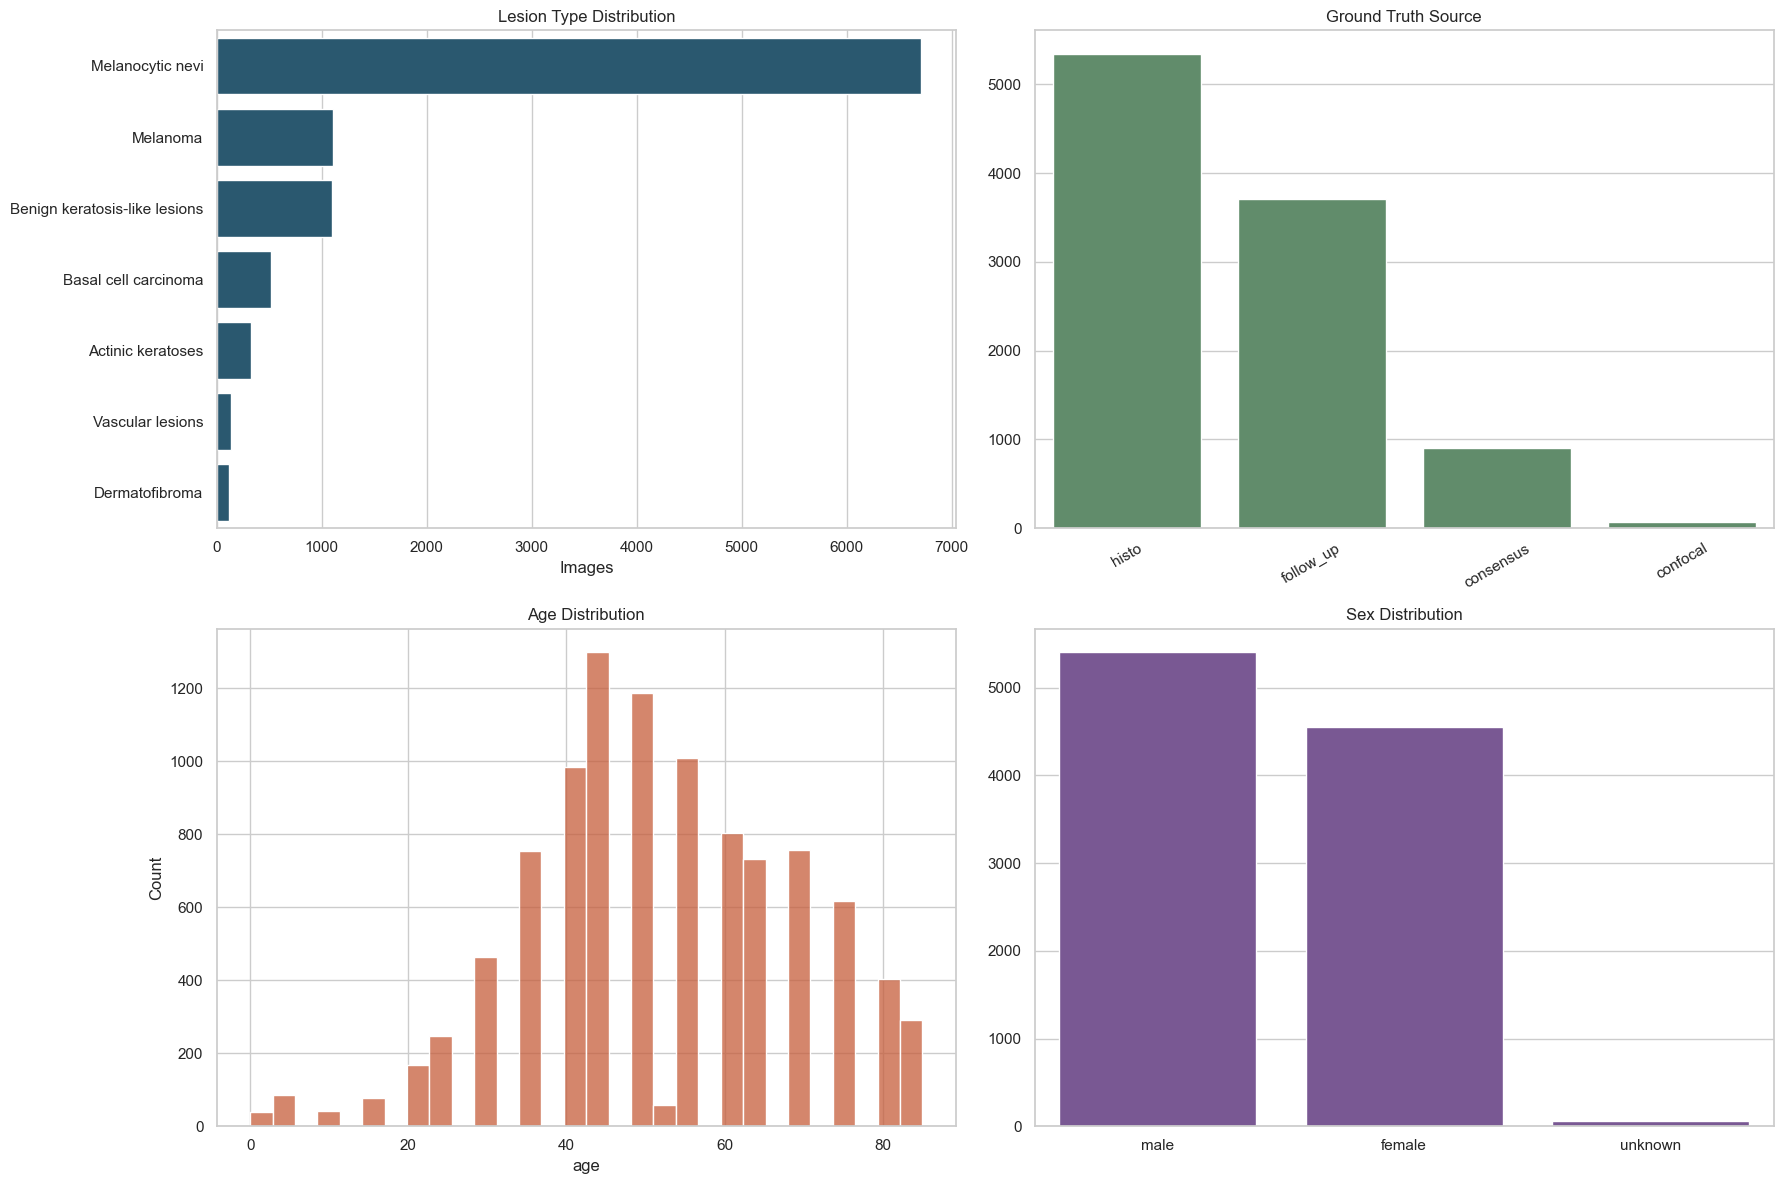

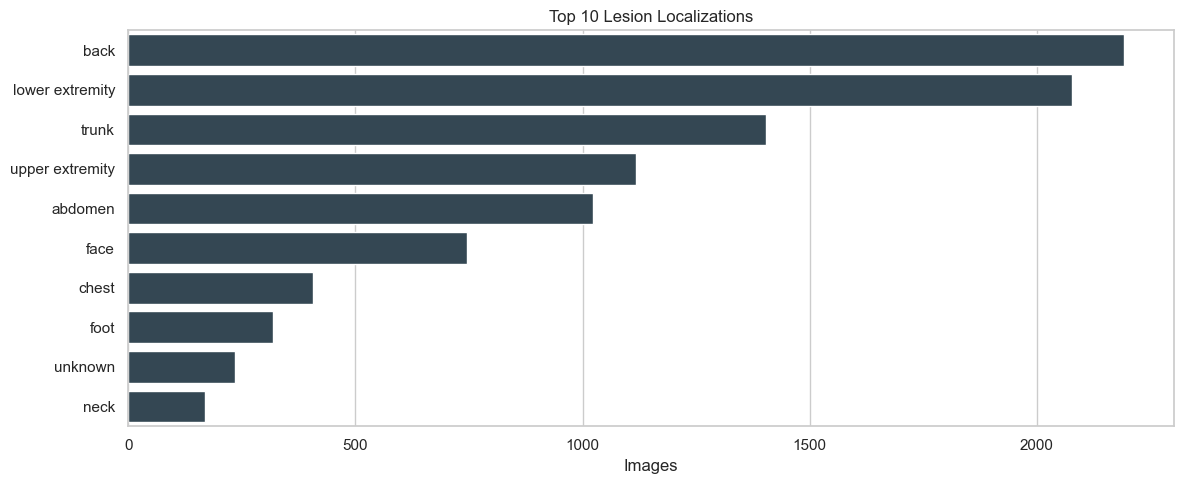

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

class_counts = skin_df["cell_type"].value_counts().reindex(CLASS_NAMES)
sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[0, 0], color="#1f5c7a")
axes[0, 0].set_title("Lesion Type Distribution")
axes[0, 0].set_xlabel("Images")
axes[0, 0].set_ylabel("")

dx_type_counts = skin_df["dx_type"].value_counts()
sns.barplot(x=dx_type_counts.index, y=dx_type_counts.values, ax=axes[0, 1], color="#5a9367")
axes[0, 1].set_title("Ground Truth Source")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.histplot(data=skin_df, x="age", bins=30, ax=axes[1, 0], color="#c65d3b")
axes[1, 0].set_title("Age Distribution")

sex_counts = skin_df["sex"].fillna("unknown").value_counts()
sns.barplot(x=sex_counts.index, y=sex_counts.values, ax=axes[1, 1], color="#7a4e9d")
axes[1, 1].set_title("Sex Distribution")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
localization_counts = skin_df["localization"].value_counts().head(10)
sns.barplot(x=localization_counts.values, y=localization_counts.index, color="#2f4858")
plt.title("Top 10 Lesion Localizations")
plt.xlabel("Images")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Prepare Images

The dataset is split with stratification, images are resized to `100x75`, and the training-set mean and standard deviation are saved for the dashboard inference flow.

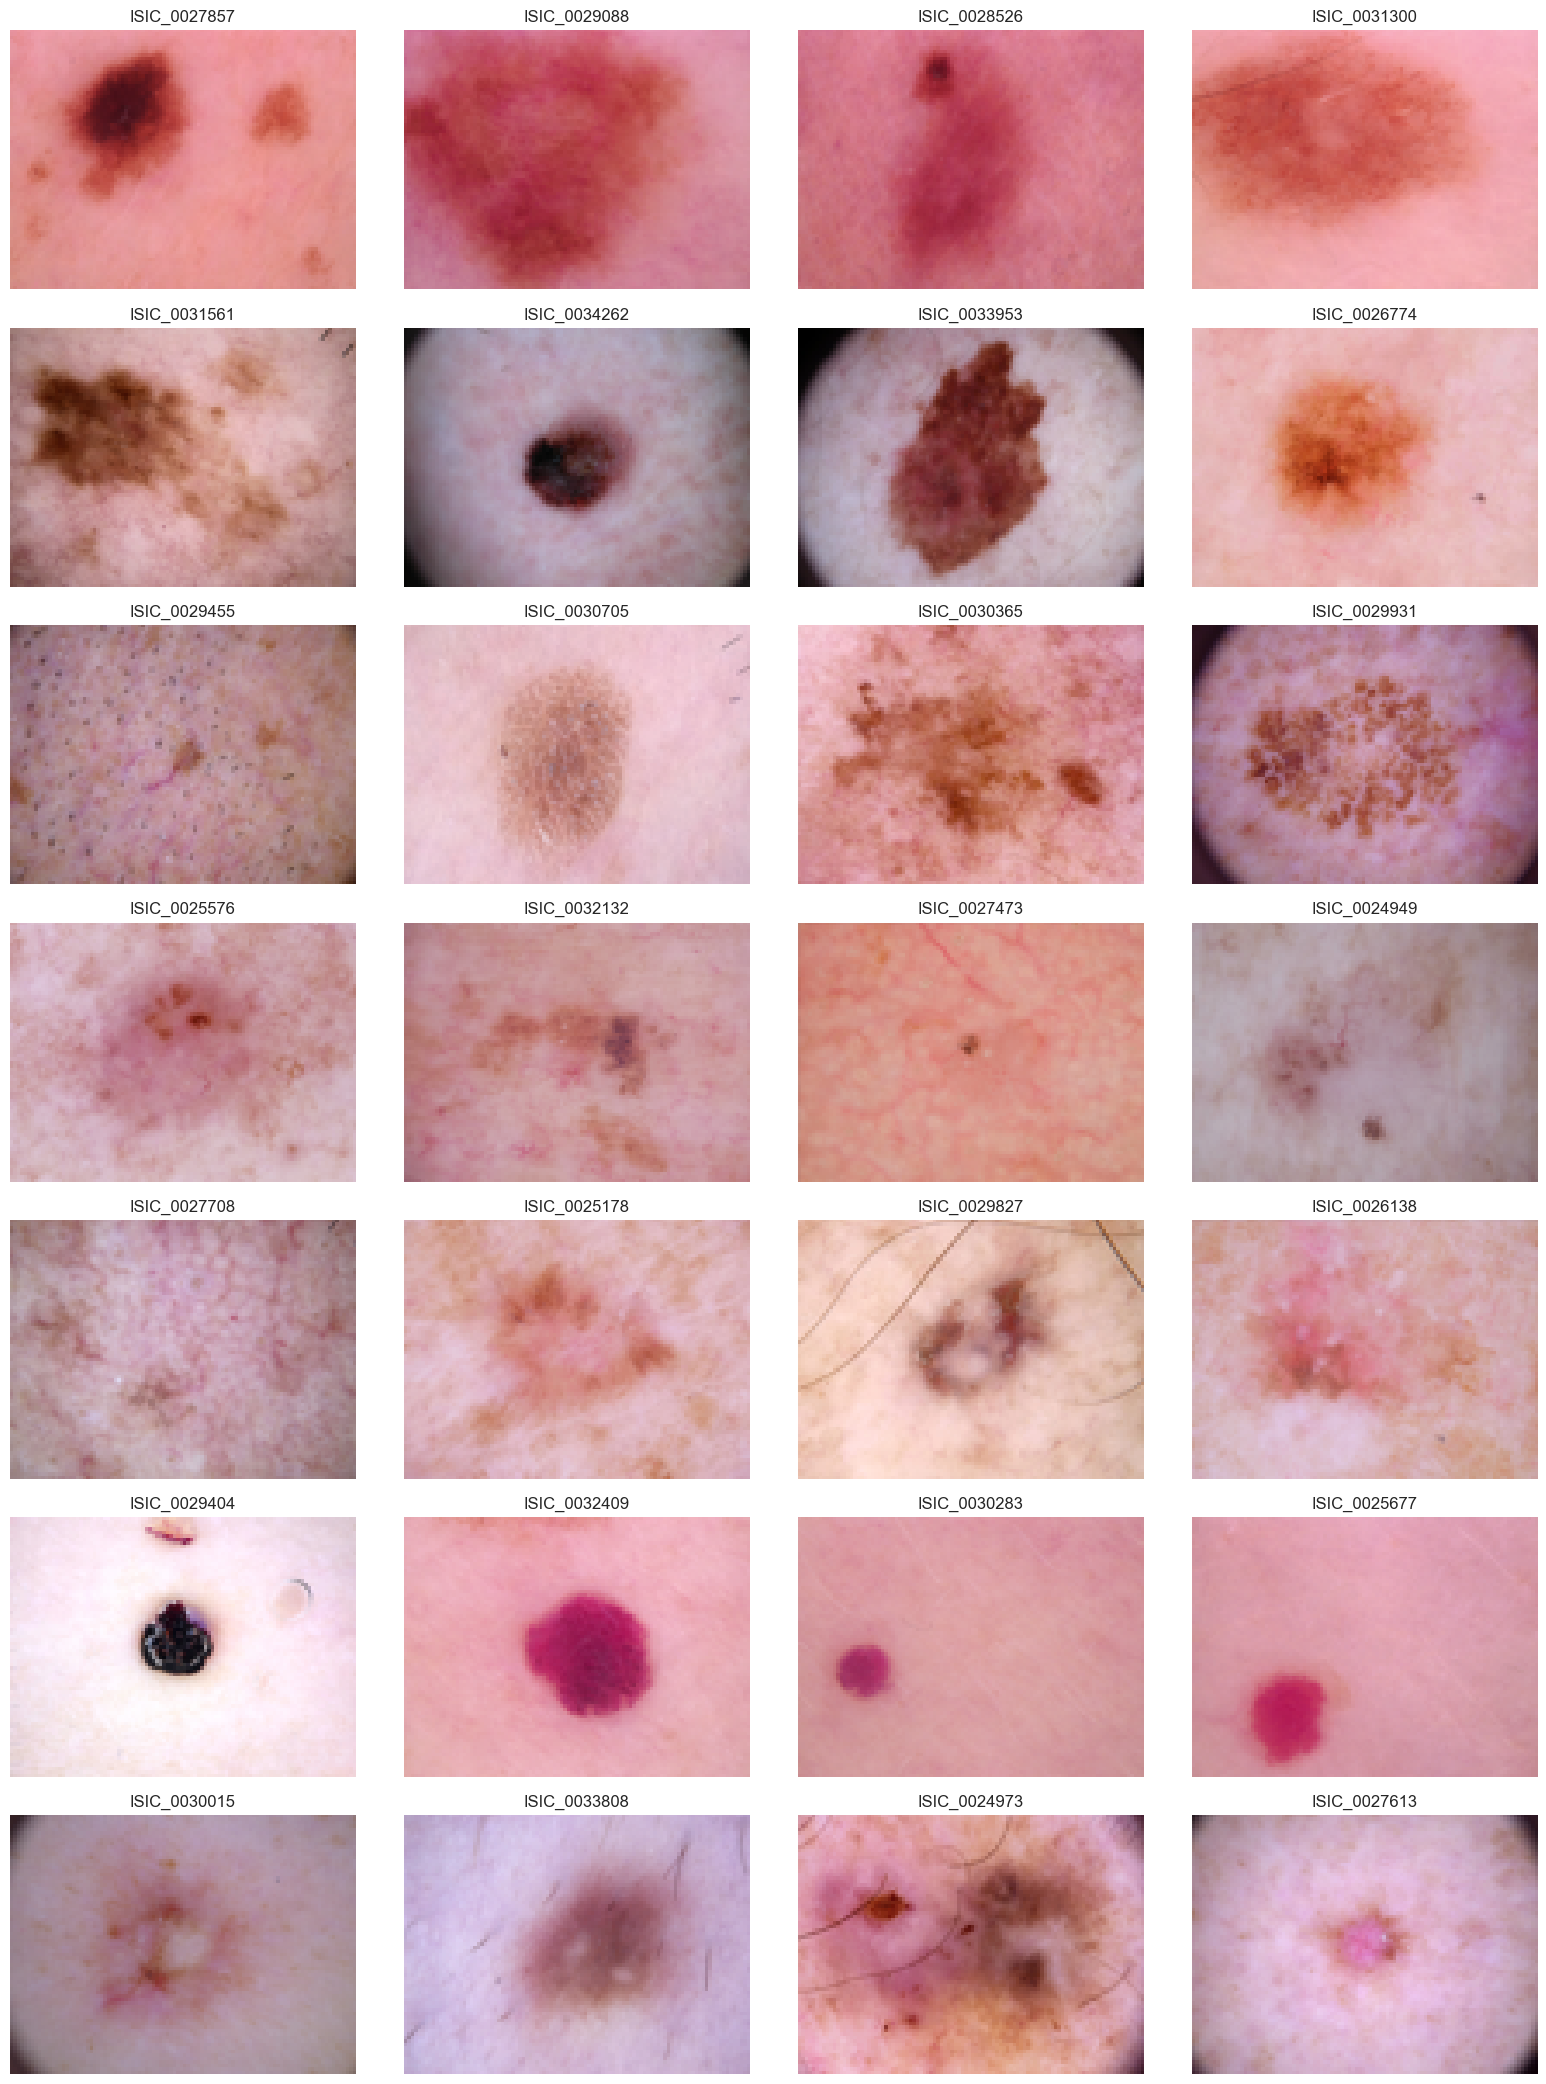

Train shape: (7210, 75, 100, 3)
Validation shape: (802, 75, 100, 3)
Test shape: (2003, 75, 100, 3)
Saved preprocessing stats to /Users/niteendewangan/Desktop/Resume Projects/SkinCancerMNIST/artifacts/preprocessing_stats.npz


In [4]:
n_samples = 4
fig, axes = plt.subplots(len(CLASS_NAMES), n_samples, figsize=(4 * n_samples, 3 * len(CLASS_NAMES)))

for row_index, lesion_name in enumerate(CLASS_NAMES):
    lesion_rows = skin_df[skin_df["cell_type"] == lesion_name]
    sample_rows = lesion_rows.sample(n=min(n_samples, len(lesion_rows)), random_state=1234)
    row_axes = np.atleast_1d(axes[row_index])
    row_axes[0].set_ylabel(lesion_name, rotation=0, labelpad=90, va="center")

    for axis in row_axes:
        axis.axis("off")

    for col_index, (_, sample_row) in enumerate(sample_rows.iterrows()):
        row_axes[col_index].imshow(load_and_resize_image(sample_row["path"]))
        row_axes[col_index].set_title(sample_row["image_id"])
        row_axes[col_index].axis("off")

plt.tight_layout()
plt.show()

image_paths = skin_df["path"].to_numpy()
labels = skin_df["cell_type_idx"].to_numpy()

train_paths, test_paths, y_train_labels, y_test_labels = split_dataset(
    image_paths,
    labels,
    labels=labels,
    test_size=0.20,
    random_state=1234,
)

train_paths, validate_paths, y_train_labels, y_validate_labels = split_dataset(
    train_paths,
    y_train_labels,
    labels=y_train_labels,
    test_size=0.10,
    random_state=1234,
)


def build_image_array(paths):
    return np.stack([load_and_resize_image(path) for path in paths]).astype("float32")


x_train = build_image_array(train_paths)
x_validate = build_image_array(validate_paths)
x_test = build_image_array(test_paths)

train_mean = float(x_train.mean())
train_std = float(x_train.std())
if train_std == 0.0:
    train_std = 1.0

x_train = (x_train - train_mean) / train_std
x_validate = (x_validate - train_mean) / train_std
x_test = (x_test - train_mean) / train_std

y_train = to_categorical(y_train_labels, num_classes=len(CLASS_NAMES))
y_validate = to_categorical(y_validate_labels, num_classes=len(CLASS_NAMES))
y_test = to_categorical(y_test_labels, num_classes=len(CLASS_NAMES))

np.savez(
    OUTPUT_DIR / "preprocessing_stats.npz",
    train_mean=train_mean,
    train_std=train_std,
    class_names=np.array(CLASS_NAMES, dtype=object),
    image_width=IMAGE_SIZE[0],
    image_height=IMAGE_SIZE[1],
)

print(f"Train shape: {x_train.shape}")
print(f"Validation shape: {x_validate.shape}")
print(f"Test shape: {x_test.shape}")
print(f"Saved preprocessing stats to {OUTPUT_DIR / 'preprocessing_stats.npz'}")


In [5]:
input_shape = (IMAGE_SIZE[1], IMAGE_SIZE[0], 3)

model = Sequential(
    [
        Input(shape=input_shape),
        Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.40),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.50),
        Dense(len(CLASS_NAMES), activation="softmax"),
    ]
)

model.summary()

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

learning_rate_reduction = ReduceLROnPlateau(
    monitor="val_accuracy",
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=0.00001,
)

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False,
)

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_validate, y_validate),
    verbose=1,
    steps_per_epoch=max(1, len(x_train) // BATCH_SIZE),
    callbacks=[learning_rate_reduction],
)


2026-06-30 17:15:05.892481: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-06-30 17:15:05.892725: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-30 17:15:05.892731: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-30 17:15:05.893100: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-30 17:15:05.893208: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 75, 100, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 100, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,752,999 (14.32 MB)

 Trainable params: 3,752,999 (14.32 MB)

...

Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-06-30 17:15:07.191929: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.6060 - loss: 1.7678 - val_accuracy: 0.6696 - val_loss: 1.0329 - learning_rate: 0.0010
Epoch 2/5
  1/225 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step - accuracy: 0.6562 - loss: 1.2822

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6562 - loss: 1.2822 - val_accuracy: 0.6696 - val_loss: 1.0199 - learning_rate: 0.0010
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.6498 - loss: 1.0623 - val_accuracy: 0.6771 - val_loss: 0.9247 - learning_rate: 0.0010
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6875 - loss: 0.7738 - val_accuracy: 0.6758 - val_loss: 0.9264 - learning_rate: 0.0010
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.6504 - loss: 0.9954 - val_accuracy: 0.6746 - val_loss: 0.8884 - learning_rate: 0.0010


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6840 - loss: 0.8765
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6656 - loss: 0.9001
Validation accuracy: 0.6746 | Validation loss: 0.8884
Test accuracy: 0.6745 | Test loss: 0.8938
Saved model to /Users/niteendewangan/Desktop/Resume Projects/SkinCancerMNIST/artifacts/skin_cancer_cnn.keras


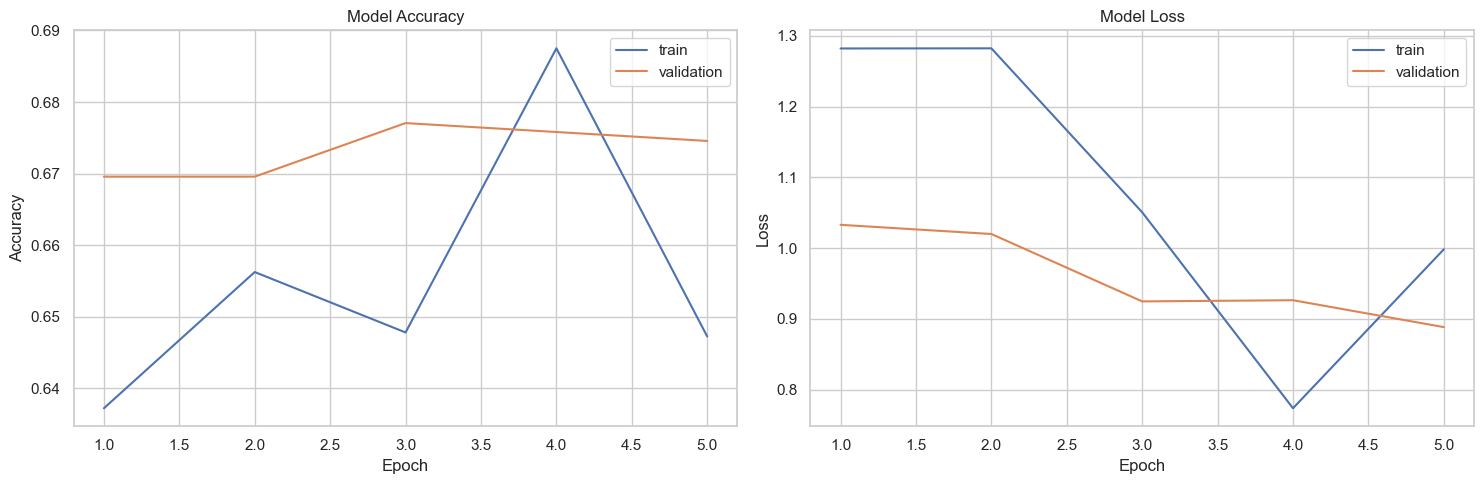

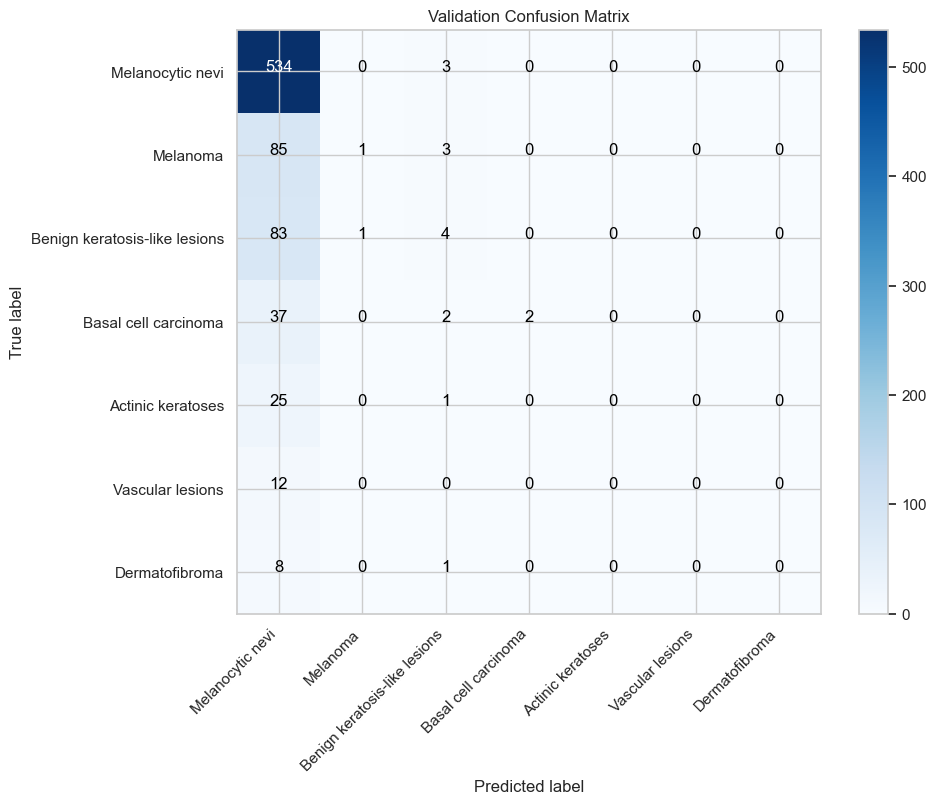

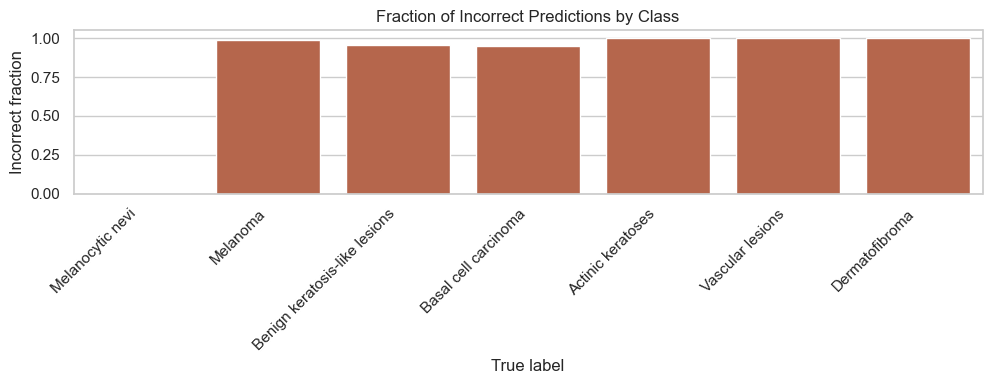

In [6]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
val_loss, val_accuracy = model.evaluate(x_validate, y_validate, verbose=1)

print(f"Validation accuracy: {val_accuracy:.4f} | Validation loss: {val_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f} | Test loss: {test_loss:.4f}")

model_path = OUTPUT_DIR / "skin_cancer_cnn.keras"
model.save(model_path)
print(f"Saved model to {model_path}")

plot_model_history(history)

y_pred = model.predict(x_validate, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_validate, axis=1)

confusion_mtx = confusion_matrix(y_true, y_pred_classes)
plot_confusion_matrix(confusion_mtx, classes=CLASS_NAMES, normalize=False, title="Validation Confusion Matrix")

label_frac_error = 1.0 - np.diag(confusion_mtx) / np.maximum(confusion_mtx.sum(axis=1), 1)
plt.figure(figsize=(10, 4))
sns.barplot(x=CLASS_NAMES, y=label_frac_error, color="#c65d3b")
plt.title("Fraction of Incorrect Predictions by Class")
plt.xlabel("True label")
plt.ylabel("Incorrect fraction")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
